In [16]:
import torch
import torch.nn.functional as F
from diffusers import DDPMPipeline, DDIMScheduler

# ── Load model ──────────────────────────────────────────────────────────────
pipe  = DDPMPipeline.from_pretrained("1aurent/ddpm-mnist")
model = pipe.unet.to("cuda")
model.eval()

# ── Quadratic schedule ───────────────────────────────────────────────────────
def make_quadratic_schedule(T=100, sigma2_min=1e-5, sigma2_max=1e-1):
    t = torch.arange(1, T + 1, dtype=torch.float64)
    sigma2              = sigma2_min + (t / T) ** 2 * (sigma2_max - sigma2_min)
    alphas_cumprod      = 1.0 - sigma2
    alphas_cumprod_prev = torch.cat([torch.tensor([1.0]), alphas_cumprod[:-1]])
    betas               = (1.0 - alphas_cumprod / alphas_cumprod_prev).clamp(1e-8, 0.999)
    alphas              = 1.0 - betas
    return betas.float(), alphas.float(), alphas_cumprod.float()

betas, alphas, alphas_cumprod = make_quadratic_schedule(T=100)
betas          = betas.cuda()
alphas         = alphas.cuda()
alphas_cumprod = alphas_cumprod.cuda()

# ── DDPM posterior parameters ────────────────────────────────────────────────
# q(xₜ₋₁ | xₜ, x₀) = N(μ̃ₜ(xₜ, x₀),  β̃ₜ)
#
# β̃ₜ = βₜ · (1 - ᾱₜ₋₁) / (1 - ᾱₜ)              ← posterior variance
# μ̃ₜ = √ᾱₜ₋₁ · βₜ / (1-ᾱₜ) · x₀
#      + √αₜ  · (1-ᾱₜ₋₁) / (1-ᾱₜ) · xₜ         ← posterior mean

def ddpm_posterior(xt, x0_hat, t_val):
    """
    Compute DDPM posterior mean μ̃ₜ and variance β̃ₜ.
    All tensors: (K, 1, 28, 28)
    """
    ab_t  = alphas_cumprod[t_val]                           # ᾱₜ
    ab_tm1 = alphas_cumprod[t_val - 1] if t_val > 0 \
             else torch.tensor(1.0, device="cuda")          # ᾱₜ₋₁
    b_t   = betas[t_val]                                    # βₜ
    a_t   = alphas[t_val]                                   # αₜ

    # Posterior variance β̃ₜ (scalar)
    beta_tilde = b_t * (1.0 - ab_tm1) / (1.0 - ab_t)
    beta_tilde = beta_tilde.clamp(min=1e-8)

    # Posterior mean μ̃ₜ (K, 1, 28, 28)
    coef_x0 = ab_tm1.sqrt() * b_t / (1.0 - ab_t)
    coef_xt = a_t.sqrt()    * (1.0 - ab_tm1) / (1.0 - ab_t)
    mu_tilde = coef_x0 * x0_hat + coef_xt * xt

    return mu_tilde, beta_tilde                             # (K,1,28,28), scalar


def predict_x0(xt, t_val):
    """
    x̂₀(xₜ) = (xₜ - √(1-ᾱₜ) · ε̂θ(xₜ,t)) / √ᾱₜ
    Requires grad on xt for the twist gradient.
    """
    ab_t       = alphas_cumprod[t_val]
    t_batch    = torch.tensor([t_val], device="cuda").expand(xt.shape[0])
    pred_noise = model(xt, t_batch).sample                  # ε̂θ  (K,1,28,28)
    x0_hat     = (xt - (1.0 - ab_t).sqrt() * pred_noise) / ab_t.sqrt()
    return x0_hat.clamp(-1.0, 1.0), pred_noise


# ── Twisting function  log p̃(y | x̂₀) ───────────────────────────────────────
# Define your observation model here.

def log_likelihood(x0_hat, observation, sigma_obs):
    """
    Gaussian observation model:  y ~ N(x₀, σ²_obs · I)
    log p̃(y | x̂₀) = -‖y - x̂₀‖² / (2 σ²_obs)    → (K,)
    """
    diff = (x0_hat - observation)                           # (K,1,28,28)
    return -diff.pow(2).sum(dim=(1, 2, 3)) / (2 * sigma_obs ** 2)


# ── Twisted proposal step ────────────────────────────────────────────────────

def twisted_proposal_step(xt, t_val, log_twist_fn):
    """
    Sample xₜ₋₁ from the twisted proposal:

        q_twist(xₜ₋₁ | xₜ) = N(μ̃ₜ + β̃ₜ · ∇ₓₜ log p̃(y | x̂₀(xₜ)),  β̃ₜ · I)

    and return log of the proposal density evaluated at the sample,
    and log of the untwisted DDPM kernel (needed for weight update).

    Returns
    -------
    xt_prev        : (K,1,28,28) — sample from twisted proposal
    log_q_twist    : (K,)        — log q_twist(xₜ₋₁ | xₜ)
    log_p_ddpm     : (K,)        — log p_θ(xₜ₋₁ | xₜ)   (untwisted)
    log_twist_curr : (K,)        — log p̃(y | x̂₀(xₜ))
    """
    # ── 1. Compute x̂₀ and posterior parameters ────────────────────────────
    xt_in = xt.detach().requires_grad_(True)
    x0_hat, pred_noise = predict_x0(xt_in, t_val)

    # ── 2. Evaluate twisting function and take gradient wrt xₜ ────────────
    log_twist_curr = log_twist_fn(x0_hat)                   # (K,)
    grad_twist     = torch.autograd.grad(
        outputs    = log_twist_curr.sum(),
        inputs     = xt_in,
        create_graph = False,
    )[0]                                                     # (K,1,28,28)

    # Detach everything before sampling
    xt         = xt.detach()
    x0_hat     = x0_hat.detach()
    grad_twist = grad_twist.detach()

    # ── 3. DDPM posterior mean and variance ───────────────────────────────
    mu_tilde, beta_tilde = ddpm_posterior(xt, x0_hat, t_val)

    # ── 4. Shifted mean of twisted proposal ──────────────────────────────
    #   μ_twist = μ̃ₜ + β̃ₜ · ∇ₓₜ log p̃(y | x̂₀(xₜ))
    mu_twist = mu_tilde + beta_tilde * grad_twist            # (K,1,28,28)

    # ── 5. Sample xₜ₋₁ ~ N(μ_twist, β̃ₜ · I) ────────────────────────────
    eps     = torch.randn_like(xt)
    xt_prev = mu_twist + beta_tilde.sqrt() * eps             # (K,1,28,28)

    # ── 6. Log densities (for weight update) ─────────────────────────────
    D = xt.shape[1] * xt.shape[2] * xt.shape[3]             # image dimension

    def log_gaussian(x, mean, var):
        """ log N(x; mean, var·I) → (K,) """
        diff = (x - mean).pow(2).sum(dim=(1, 2, 3))
        return -0.5 * (D * var.log() + diff / var)

    log_q_twist = log_gaussian(xt_prev, mu_twist,  beta_tilde)  # twisted kernel
    log_p_ddpm  = log_gaussian(xt_prev, mu_tilde,  beta_tilde)  # untwisted kernel

    return xt_prev, log_q_twist, log_p_ddpm, log_twist_curr.detach()


# ── TDS Main Loop ────────────────────────────────────────────────────────────

def tds(
    model,
    log_twist_fn,                   # callable: (x0_hat) → (K,) log-likelihoods
    K              = 16,            # number of particles
    device         = "cuda",
):
    """
    Twisted Diffusion Sampler (TDS).

    Weight update at each step:

      log wₜ += log p̃(y|x̂₀(xₜ₋₁))          ← new twist at xₜ₋₁
              + log p_θ(xₜ₋₁|xₜ)             ← untwisted DDPM kernel
              - log q_twist(xₜ₋₁|xₜ)         ← twisted proposal (cancels shift)
              - log p̃(y|x̂₀(xₜ))              ← old twist at xₜ (cancels recursively)

    Returns
    -------
    samples : (K, 1, 28, 28)
    weights : (K,) normalized importance weights
    """
    T          = 100
    timesteps  = list(range(T - 1, -1, -1))                 # T-1 → 0
    log_w      = torch.zeros(K, device=device)
    ess_hist   = []

    # ── Initialize x_T ~ N(0, I) ─────────────────────────────────────────
    x = torch.randn(K, 1, 28, 28, device=device)

    # Initial twisting value at t=T-1
    with torch.no_grad():
        x0_init, _         = predict_x0(x, timesteps[0])
    log_twist_prev         = log_twist_fn(x0_init).detach()

    # ── Reverse loop ──────────────────────────────────────────────────────
    for t_val in timesteps:

        if t_val == 0:
            # Last step: no more transitions, just reweight
            with torch.no_grad():
                x0_hat, _ = predict_x0(x, 0)
            log_twist_curr = log_twist_fn(x0_hat).detach()
            log_w         += log_twist_curr - log_twist_prev
            break

        # 1. Twisted proposal step
        xt_prev, log_q, log_p, log_twist_curr = twisted_proposal_step(
            x, t_val, log_twist_fn
        )

        # 2. Compute twisting at xₜ₋₁ (next state)
        with torch.no_grad():
            x0_next, _     = predict_x0(xt_prev, t_val - 1)
        log_twist_next     = log_twist_fn(x0_next).detach()

        # 3. Weight update:
        #   log w += log p̃(y|x̂₀(xₜ₋₁)) + log p_θ(xₜ₋₁|xₜ)
        #          - log q_twist(xₜ₋₁|xₜ) - log p̃(y|x̂₀(xₜ))
        log_w += log_twist_next + log_p - log_q - log_twist_curr

        # 4. Normalize + ESS
        log_w_norm = log_w - torch.logsumexp(log_w, dim=0)
        w_norm     = log_w_norm.exp()
        ess        = 1.0 / w_norm.pow(2).sum().item()
        ess_hist.append(ess / K)

        # 5. Resample if ESS < K/2
        if ess < K / 2:
            idx            = systematic_resample(w_norm, K)
            xt_prev        = xt_prev[idx]
            log_twist_next = log_twist_next[idx]
            log_w          = torch.zeros(K, device=device)

        x              = xt_prev
        log_twist_prev = log_twist_next

    # Final normalized weights
    log_w_norm = log_w - torch.logsumexp(log_w, dim=0)
    return x, log_w_norm.exp(), ess_hist


def systematic_resample(weights, K):
    positions = (torch.arange(K, device=weights.device) +
                 torch.rand(1, device=weights.device)) / K
    cumsum    = weights.cumsum(dim=0)
    return torch.searchsorted(cumsum, positions).clamp(0, K - 1)

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 31.35it/s]


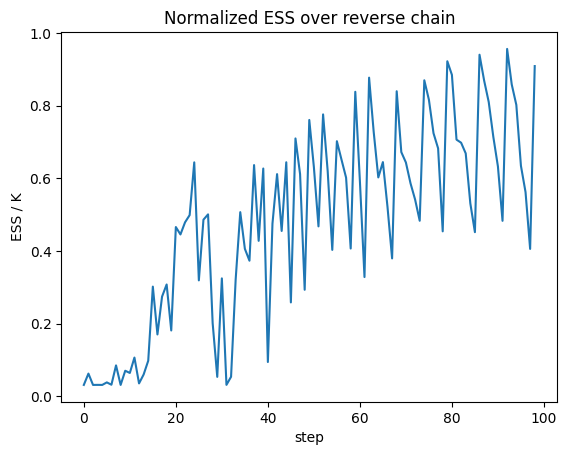

In [17]:
from torchvision import datasets, transforms
from torchvision.utils import save_image

transform   = transforms.Compose([transforms.ToTensor(),
                                   transforms.Normalize([0.5], [0.5])])
dataset     = datasets.MNIST("./data", train=False, download=True, transform=transform)
clean       = dataset[0][0].unsqueeze(0).cuda()

# Corrupt image
sigma_obs   = 0.1
noisy_obs   = clean + sigma_obs * torch.randn_like(clean)

# Define twisting function (partial application of observation)
log_twist_fn = lambda x0_hat: log_likelihood(x0_hat, noisy_obs, sigma_obs)

# Run TDS
samples, weights, ess_hist = tds(
    model,
    log_twist_fn = log_twist_fn,
    K            = 32,
)

best = samples[weights.argmax()].unsqueeze(0).cpu()
save_image(torch.cat([clean.cpu(), noisy_obs.cpu(), best]),
           "tds_result.png", nrow=3, normalize=True)

import matplotlib.pyplot as plt
plt.plot(ess_hist)
plt.xlabel("step"); plt.ylabel("ESS / K")
plt.title("Normalized ESS over reverse chain")
plt.savefig("ess.png")